installation 


In [8]:
%pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd 

data = pd.read_csv("/Users/spurge/Desktop/anamoly Detection /scatter_plot_dataset.csv")

data.head()

,feature_x,feature_y
0,67.64,105.29
1,54.00,80.66
2,59.79,100.64
3,72.41,106.27
4,68.68,99.54


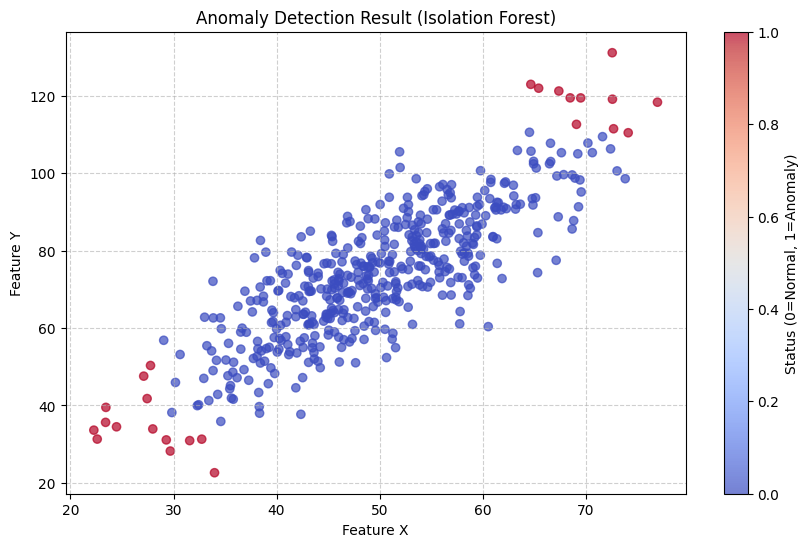

Anomalies detected: 25 out of 500 points


,feature_x,feature_y,anomaly,status
0,67.64,105.29,1,0
1,54.00,80.66,1,0
2,59.79,100.64,1,0
3,72.41,106.27,1,0
4,68.68,99.54,1,0


In [10]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 1. Implement Isolation Forest for anomaly detection
# we use feature_x and feature_y for detection
model = IsolationForest(contamination=0.05, random_state=42)
data['anomaly'] = model.fit_predict(data[['feature_x', 'feature_y']])

# 2. Map anomalies to 0 (normal) and 1 (anomaly)
# IsolationForest returns -1 for anomalies and 1 for normal points
data['status'] = data['anomaly'].map({1: 0, -1: 1})

# 3. Fix ValueError in scatter plot and visualize
plt.figure(figsize=(10, 6))
# feature_x is iloc[:, 0], feature_y is iloc[:, 1]
scatter = plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['status'], cmap='coolwarm', alpha=0.7)

plt.colorbar(scatter, label='Status (0=Normal, 1=Anomaly)')
plt.xlabel('Feature X')
plt.ylabel('Feature Y')
plt.title('Anomaly Detection Result (Isolation Forest)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Anomalies detected: {data['status'].sum()} out of {len(data)} points")
data.head()

In [11]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(contamination=0.1)

clf.fit(data)

y_pred = clf.predict(data)

In [12]:
y_pred  

array([ 1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,
        1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1, -1,  1

In [13]:
import numpy as np 

index_outlier=np.where(y_pred==-1)[0]
index_outlier

array([  3,  11,  20,  24,  33,  43,  63,  80, 100, 108, 110, 113, 127,
       144, 151, 183, 185, 189, 193, 198, 218, 224, 237, 264, 271, 278,
       279, 292, 301, 327, 334, 336, 350, 356, 377, 382, 385, 398, 404,
       422, 427, 443, 455, 457, 465, 468, 470, 474, 485, 494])

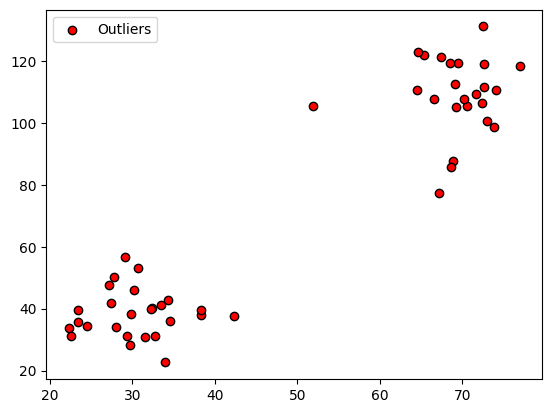

In [14]:
# Fix InvalidIndexError: Use .iloc for positional indexing in Pandas
# and fix the syntax for colors
plt.scatter(data.iloc[index_outlier, 0], data.iloc[index_outlier, 1], c='r', edgecolors='black', label='Outliers')
plt.legend()
plt.show()